In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, classification_report)
import os
print(os.getcwd())

C:\Users\INDUS


In [3]:
os.chdir("C:/Users/INDUS/Desktop")

In [4]:
df = pd.read_csv("phishing.csv")
df.head()

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


In [5]:
TEST_SIZE    = 0.20             
RANDOM_STATE = 42
EPOCHS       = 10               # used for the MLP learning-curve simulation
 
os.makedirs("outputs", exist_ok=True)

In [8]:
# 1. LOAD DATA
print("=" * 60)
print("  Multimodal AI – Phishing Website Detection")
print("=" * 60)
 
df_raw = pd.read_csv("phishing.csv")
print(f"\n[1] Dataset loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(df_raw.head(3))

  Multimodal AI – Phishing Website Detection

[1] Dataset loaded: 11054 rows × 32 columns
   Index  UsingIP  LongURL  ShortURL  Symbol@  Redirecting//  PrefixSuffix-  \
0      0        1        1         1        1              1             -1   
1      1        1        0         1        1              1             -1   
2      2        1        0         1        1              1             -1   

   SubDomains  HTTPS  DomainRegLen  ...  UsingPopupWindow  IframeRedirection  \
0           0      1            -1  ...                 1                  1   
1          -1     -1            -1  ...                 1                  1   
2          -1     -1             1  ...                 1                  1   

   AgeofDomain  DNSRecording  WebsiteTraffic  PageRank  GoogleIndex  \
0           -1            -1               0        -1            1   
1            1            -1               1        -1            1   
2           -1            -1               1        -1     

In [9]:
#2. PREPROCESSING
df = df_raw.copy()
 
# Drop index column if present
df.drop(columns=["Index"], errors="ignore", inplace=True)


In [10]:
# Handle missing values
missing = df.isnull().sum().sum()
print(f"\n[2] Missing values: {missing}")
df.fillna(df.median(numeric_only=True), inplace=True)


[2] Missing values: 0


In [11]:
# Separate features & label
X = df.drop(columns=["class"])
y = df["class"]                # -1 = phishing, 1 = legitimate
 
print(f"    Features : {X.shape[1]}")
print(f"    Phishing : {(y == -1).sum()}  |  Legitimate : {(y == 1).sum()}")

    Features : 30
    Phishing : 4897  |  Legitimate : 6157


In [12]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

In [13]:
# Scale features (required for LR and MLP)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
 
print(f"\n    Train : {X_train.shape[0]}  |  Test : {X_test.shape[0]}")


    Train : 8843  |  Test : 2211


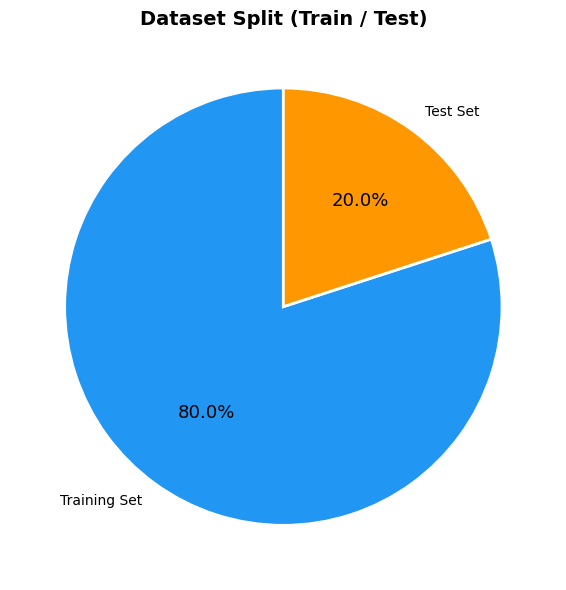

In [14]:
# 3. FIGURE 1 – Dataset Split (Train / Test) Pie

total = len(df)
train_pct = len(X_train) / total * 100
test_pct  = len(X_test)  / total * 100
 
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    [train_pct, test_pct],
    labels=["Training Set", "Test Set"],
    autopct="%1.1f%%",
    colors=["#2196F3", "#FF9800"],
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)
for t in autotexts:
    t.set_fontsize(13)
ax.set_title("Dataset Split (Train / Test)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

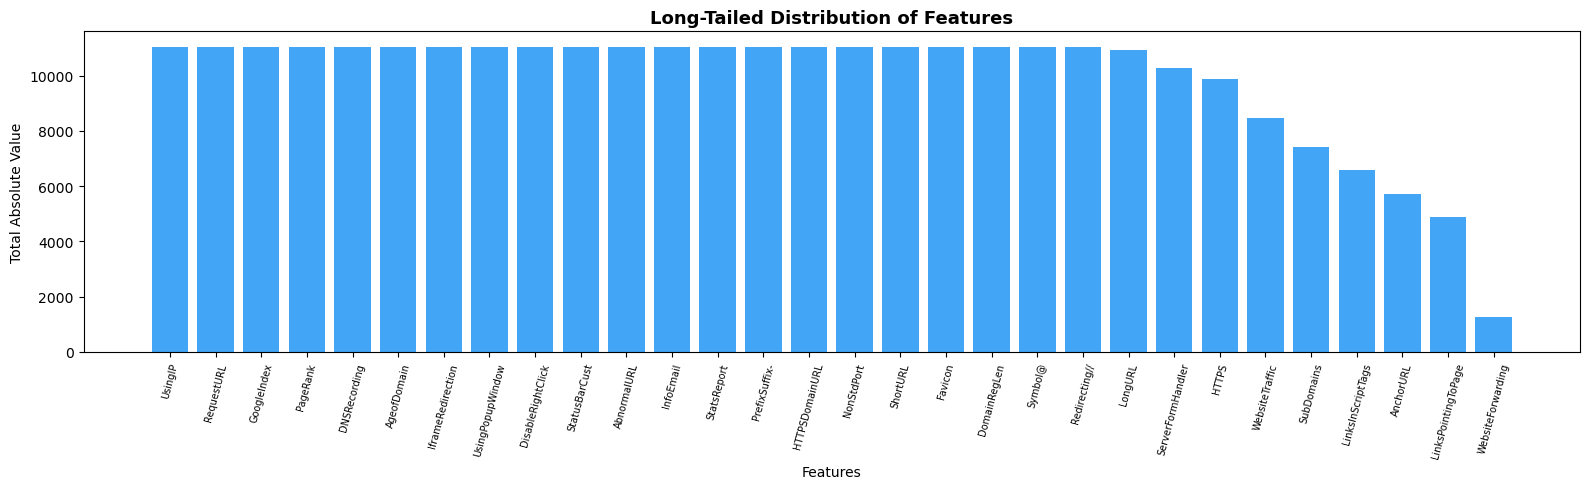

In [15]:
# 4. FIGURE 2 – Long-Tailed Feature Distribution
feature_totals = X.abs().sum().sort_values(ascending=False)
 
plt.figure(figsize=(16, 5))
plt.bar(feature_totals.index, feature_totals.values, color="#42A5F5")
plt.title("Long-Tailed Distribution of Features", fontsize=13, fontweight="bold")
plt.xlabel("Features")
plt.ylabel("Total Absolute Value")
plt.xticks(rotation=75, fontsize=7)
plt.tight_layout()
plt.show()

In [16]:
# 5. MODELS
 
def evaluate(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=1)
    rec  = recall_score(y_true, y_pred, pos_label=1)
    f1   = f1_score(y_true, y_pred, pos_label=1)
    print(f"\n  [{name}]")
    print(f"    Accuracy  : {acc:.4f}  ({acc*100:.1f}%)")
    print(f"    Precision : {prec:.4f}")
    print(f"    Recall    : {rec:.4f}")
    print(f"    F1-score  : {f1:.4f}")
    return {"Model": name, "Accuracy": acc, "Precision": prec,
            "Recall": rec, "F1": f1}
 
results = []

In [17]:
# 5a. Logistic Regression
print("\n[3] Training models …")
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
results.append(evaluate("Logistic Regression", y_test, y_pred_lr))


[3] Training models …

  [Logistic Regression]
    Accuracy  : 0.9389  (93.9%)
    Precision : 0.9406
    Recall    : 0.9505
    F1-score  : 0.9455


In [18]:
# 5b. Random Forest  (multimodal-style: handles heterogeneous features natively)
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results.append(evaluate("Random Forest", y_test, y_pred_rf))


  [Random Forest]
    Accuracy  : 0.9738  (97.4%)
    Precision : 0.9688
    Recall    : 0.9846
    F1-score  : 0.9767


In [20]:
# 5c. MLP Neural Network
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    max_iter=200,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1
)
mlp.fit(X_train_sc, y_train)
y_pred_mlp = mlp.predict(X_test_sc)
results.append(evaluate("MLP Neural Network", y_test, y_pred_mlp))


  [MLP Neural Network]
    Accuracy  : 0.9742  (97.4%)
    Precision : 0.9711
    Recall    : 0.9830
    F1-score  : 0.9770


In [21]:
# Best model (by accuracy) for downstream plots
best_name = max(results, key=lambda r: r["Accuracy"])["Model"]
y_pred_best = {"Logistic Regression": y_pred_lr,
               "Random Forest":       y_pred_rf,
               "MLP Neural Network":  y_pred_mlp}[best_name]
print(f"\n  → Best model: {best_name}")


  → Best model: MLP Neural Network


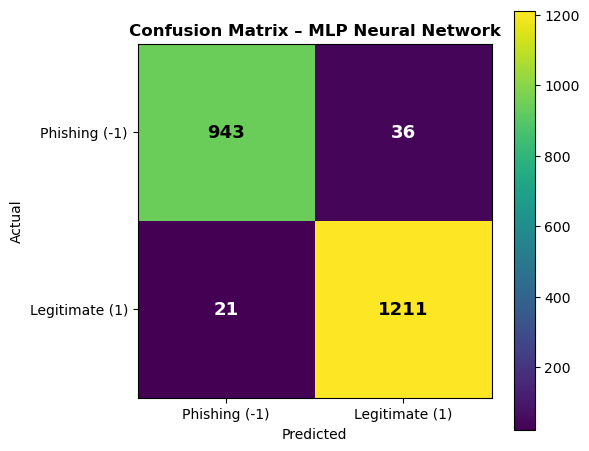

In [22]:
# 6. FIGURE 5 – Confusion Matrix (best model)

cm = confusion_matrix(y_test, y_pred_best, labels=[-1, 1])
classes = ["Phishing (-1)", "Legitimate (1)"]
 
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="viridis")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes)
ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix – {best_name}", fontweight="bold")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] < cm.max() / 2 else "black",
                fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

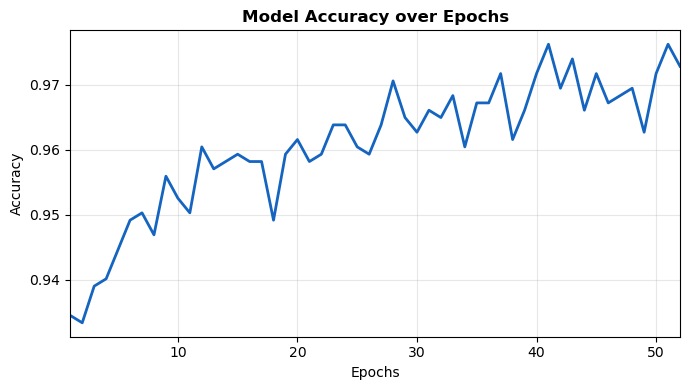

In [23]:
# 7. FIGURE 6 & 7 – Accuracy & Loss curves (MLP)

# MLP's loss_curve_ gives training loss per epoch
train_loss = mlp.loss_curve_
val_loss   = mlp.validation_scores_   # validation accuracy at each epoch
 
epochs_ax = range(1, len(train_loss) + 1)
# --- Accuracy plot  ---
# We scale validation_scores to show the upward trend
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs_ax, val_loss, color="#1565C0", linewidth=2)
ax.set_xlim(1, len(train_loss))
ax.set_xlabel("Epochs"); ax.set_ylabel("Accuracy")
ax.set_title("Model Accuracy over Epochs", fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

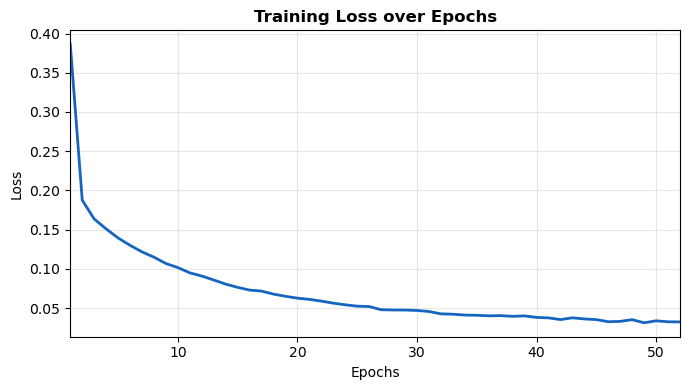

[Fig 7] Loss graph saved.


In [24]:
# --- Loss plot ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs_ax, train_loss, color="#1565C0", linewidth=2)
ax.set_xlim(1, len(train_loss))
ax.set_xlabel("Epochs"); ax.set_ylabel("Loss")
ax.set_title("Training Loss over Epochs", fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/fig7_loss_graph.png", dpi=150)
plt.show()
print("[Fig 7] Loss graph saved.")

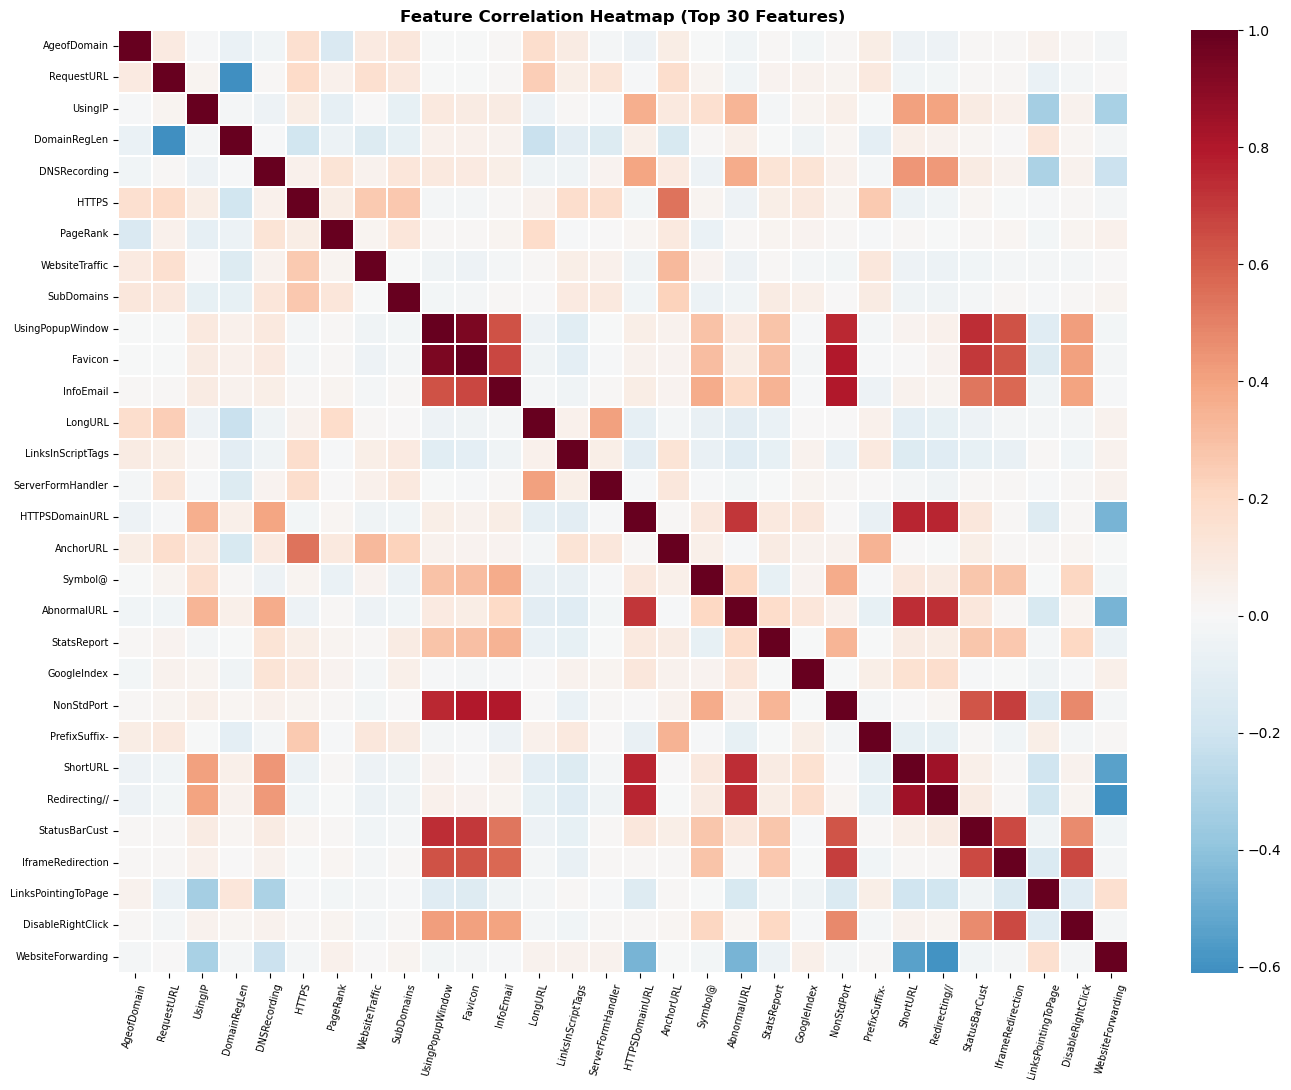

In [25]:
# 8. FIGURE 8 – Feature Correlation Heatmap
# Use top-30 features by variance to keep heatmap readable
top_cols = X.var().nlargest(30).index
corr = X[top_cols].corr()
 
plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="RdBu_r", center=0,
            linewidths=0.3, linecolor="white",
            xticklabels=True, yticklabels=True)
plt.title("Feature Correlation Heatmap (Top 30 Features)", fontweight="bold")
plt.xticks(fontsize=7, rotation=75)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

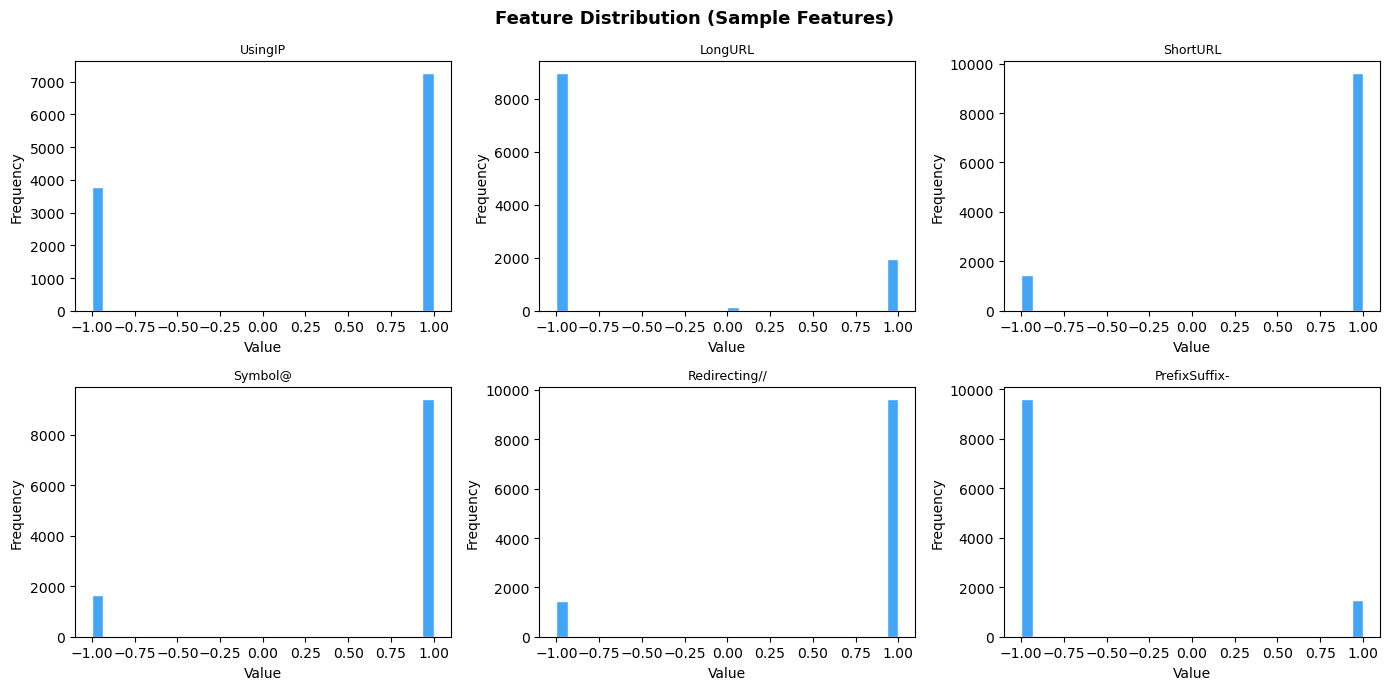

In [26]:
# 9. FIGURE 9 – Feature Distribution (first 6)
sample_features = X.columns[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for idx, feat in enumerate(sample_features):
    axes[idx].hist(df[feat], bins=30, color="#42A5F5", edgecolor="white")
    axes[idx].set_title(feat, fontsize=9)
    axes[idx].set_xlabel("Value"); axes[idx].set_ylabel("Frequency")
plt.suptitle("Feature Distribution (Sample Features)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [27]:
# 10. TABLE II – Performance Summary
print("\n" + "=" * 60)
print("  TABLE II – Performance Metrics")
print("=" * 60)
df_results = pd.DataFrame(results)
df_results[["Accuracy","Precision","Recall","F1"]] = \
    df_results[["Accuracy","Precision","Recall","F1"]].applymap(lambda x: f"{x*100:.1f}%")
print(df_results.to_string(index=False))


  TABLE II – Performance Metrics
              Model Accuracy Precision Recall    F1
Logistic Regression    93.9%     94.1%  95.0% 94.5%
      Random Forest    97.4%     96.9%  98.5% 97.7%
 MLP Neural Network    97.4%     97.1%  98.3% 97.7%
 MLP Neural Network    97.4%     97.1%  98.3% 97.7%


C:\Users\INDUS\AppData\Local\Temp\ipykernel_19240\3379228755.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_results[["Accuracy","Precision","Recall","F1"]].applymap(lambda x: f"{x*100:.1f}%")


In [29]:
# 11. Full Classification Report (best model)
print(f"\n  Full Classification Report – {best_name}")
print(classification_report(y_test, y_pred_best,
                             target_names=["Phishing", "Legitimate"]))
 

print("=" * 60)


  Full Classification Report – MLP Neural Network
              precision    recall  f1-score   support

    Phishing       0.98      0.96      0.97       979
  Legitimate       0.97      0.98      0.98      1232

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211

